# Stage 2 — Feature Engineering

**What this notebook covers:**

| Step | Task |
|---|---|
| 1 | Load cleaned Parquet output from Stage 1 |
| 2 | Audit columns — identify leakage, redundant, and useful features |
| 3 | Create interaction features (`family_size`, `is_alone`, `fare_per_person`) |
| 4 | Train / test split **before** fitting any transformer |
| 5 | Build a scikit-learn `Pipeline` (one-hot encoding + scaling) |
| 6 | Fit Pipeline **only on training data** — transform both splits |
| 7 | Verify no leakage occurred |
| 8 | Save the fitted Pipeline to `models/feature_pipeline.pkl` |
| 9 | Save feature-engineered splits to `data/processed/` |

**Why a Pipeline?**  
Without a Pipeline you risk **training-serving skew**: fitting a scaler on the full dataset leaks test statistics into training. A Pipeline guarantees the same transformations are applied identically at train time and serving time.

**Input**: `data/processed/titanic_clean.parquet`  
**Outputs**: `models/feature_pipeline.pkl`, `data/processed/X_train.parquet`, `data/processed/X_test.parquet`, `data/processed/y_train.csv`, `data/processed/y_test.csv`


## Step 1 — Imports & Setup


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
print('All libraries imported successfully.')


All libraries imported successfully.


## Step 2 — Load Cleaned Data from Stage 1

We read from `data/processed/titanic_clean.parquet` — the validated output of Stage 1.  
This is the **contract between stages**: Stage 2 must not re-do Stage 1 work.


In [2]:
parquet_path = '../data/processed/titanic_clean.parquet'
df = pd.read_parquet(parquet_path)

print(f'Loaded: {df.shape[0]} rows × {df.shape[1]} columns')
print(f'\nColumns: {list(df.columns)}')
print(f'\nDtypes:\n{df.dtypes}')


Loaded: 784 rows × 15 columns

Columns: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']

Dtypes:
survived          int64
pclass            int64
sex                 str
age             float64
sibsp             int64
parch             int64
fare            float64
embarked            str
class          category
who                 str
adult_male         bool
deck           category
embark_town         str
alive               str
alone              bool
dtype: object


## Step 3 — Column Audit: Leakage & Redundancy

Before building features, audit every column:

| Column | Keep? | Reason |
|---|---|---|
| `survived` | ✅ Target | What we predict |
| `pclass` | ✅ Feature | Ticket class |
| `sex` | ✅ Feature | Encode → binary |
| `age` | ✅ Feature | Scale |
| `sibsp` | ✅ Feature | Used in family_size |
| `parch` | ✅ Feature | Used in family_size |
| `fare` | ✅ Feature | Scale |
| `embarked` | ✅ Feature | One-hot encode |
| `alone` | ✅ Feature | Keep as binary |
| `class` | ❌ Redundant | Same info as `pclass` (string vs int) |
| `who` | ❌ Derived | Derived from `sex` + `age` — multicollinearity |
| `adult_male` | ❌ Derived | Derived from `sex` + `age` |
| `deck` | ❌ Too sparse | ~77% of values are NaN |
| `embark_town` | ❌ Redundant | Same as `embarked` (full city name) |
| `alive` | ❌ **LEAKAGE** | `alive` = 'yes'/'no' is just `survived` (1/0) renamed — gives 100% accuracy & fails in production! |


In [3]:
# Demonstrate the leakage before dropping
print('=== alive vs survived — first 10 rows ===')
print(df[['survived', 'alive']].head(10).to_string())
print(f"\nalive unique values: {sorted(df['alive'].dropna().unique())}")
print('\n→ "yes" = survived=1  |  "no" = survived=0  — pure leakage, MUST drop!')


=== alive vs survived — first 10 rows ===
   survived alive
0         0    no
1         1   yes
2         1   yes
3         1   yes
4         0    no
5         0    no
6         0    no
7         0    no
8         1   yes
9         1   yes

alive unique values: ['no', 'yes']

→ "yes" = survived=1  |  "no" = survived=0  — pure leakage, MUST drop!


In [4]:
# Drop leaky and redundant columns
drop_cols = ['class', 'who', 'adult_male', 'deck', 'embark_town', 'alive']
df = df.drop(columns=drop_cols)

print(f'Remaining columns ({len(df.columns)}): {list(df.columns)}')
print(f'\nMissing values:\n{df.isnull().sum()}')


Remaining columns (9): ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'alone']

Missing values:
survived    0
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
alone       0
dtype: int64


## Step 4 — Create Interaction Features

New features derived from existing ones can capture relationships that individual features miss.

| New Feature | Formula | Intuition |
|---|---|---|
| `family_size` | `sibsp + parch + 1` | Total people in the passenger's group (including self) |
| `is_alone` | `family_size == 1` → int | Travelling completely alone — historically lower survival |
| `fare_per_person` | `fare / family_size` | Normalise fare by group size — better socioeconomic proxy |


In [5]:
df['family_size']     = df['sibsp'] + df['parch'] + 1
df['is_alone']        = (df['family_size'] == 1).astype(int)
df['fare_per_person'] = (df['fare'] / df['family_size']).round(4)

print('=== New interaction features (first 8 rows) ===')
print(df[['sibsp', 'parch', 'family_size', 'is_alone', 'fare', 'fare_per_person']].head(8).to_string())
print(f'\nFamily size distribution:\n{df["family_size"].value_counts().sort_index()}')


=== New interaction features (first 8 rows) ===
   sibsp  parch  family_size  is_alone     fare  fare_per_person
0      1      0            2         0   7.2500           3.6250
1      1      0            2         0  71.2833          35.6416
2      0      0            1         1   7.9250           7.9250
3      1      0            2         0  53.1000          26.5500
4      0      0            1         1   8.0500           8.0500
5      0      0            1         1   8.4583           8.4583
6      0      0            1         1  51.8625          51.8625
7      3      1            5         0  21.0750           4.2150

Family size distribution:
family_size
1     446
2     154
3     101
4      28
5      13
6      22
7      12
8       6
11      2
Name: count, dtype: int64


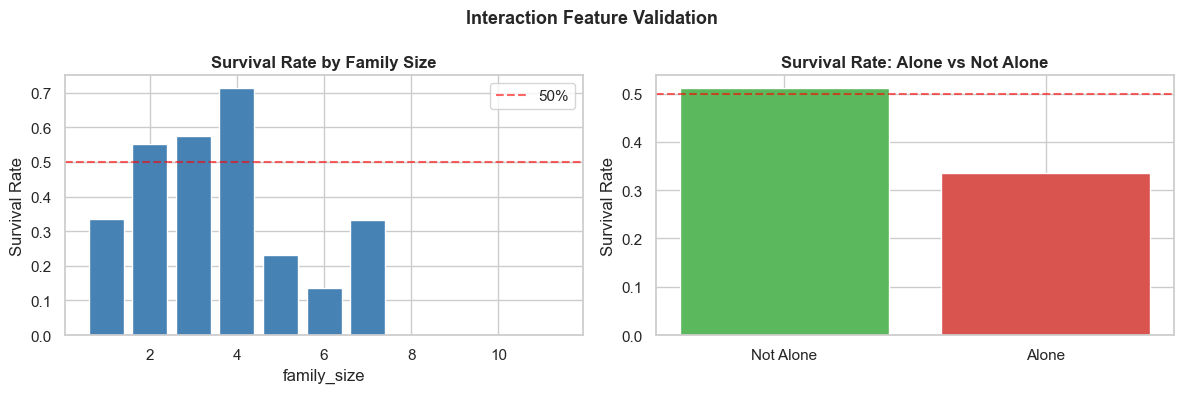

In [6]:
# Visualise survival rate by interaction features
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

family_survival = df.groupby('family_size')['survived'].mean()
axes[0].bar(family_survival.index, family_survival.values, color='steelblue', edgecolor='white')
axes[0].axhline(0.5, color='red', linestyle='--', alpha=0.6, label='50%')
axes[0].set_title('Survival Rate by Family Size', fontweight='bold')
axes[0].set_xlabel('family_size')
axes[0].set_ylabel('Survival Rate')
axes[0].legend()

alone_survival = df.groupby('is_alone')['survived'].mean()
axes[1].bar(['Not Alone', 'Alone'], alone_survival.values,
            color=['#5cb85c', '#d9534f'], edgecolor='white')
axes[1].axhline(0.5, color='red', linestyle='--', alpha=0.6)
axes[1].set_title('Survival Rate: Alone vs Not Alone', fontweight='bold')
axes[1].set_ylabel('Survival Rate')

plt.suptitle('Interaction Feature Validation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## Step 5 — Train / Test Split

**CRITICAL**: The split must happen **before** fitting any scaler or encoder.  
If you fit on the full dataset first, test statistics leak into training — your model appears to generalise better than it actually does.

```
WRONG:  scaler.fit(X_all) → split → transform(X_train), transform(X_test)
RIGHT:  split → scaler.fit(X_train) → transform(X_train), transform(X_test)
```

We use `stratify=y` to preserve the class ratio (~38% survived) in both splits.


In [7]:
TARGET = 'survived'
X = df.drop(columns=[TARGET])
y = df[TARGET]

print(f'Feature matrix shape: {X.shape}')
print(f'Target shape:         {y.shape}')
print(f'Target balance:       {y.value_counts(normalize=True).round(3).to_dict()}')

# Stratified 80/20 split — split BEFORE any fitting
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y          # preserve class balance in both splits
)

print(f'\nTrain: {len(X_train)} rows  |  Test: {len(X_test)} rows')
print(f'Train target balance: {y_train.value_counts(normalize=True).round(3).to_dict()}')
print(f'Test  target balance: {y_test.value_counts(normalize=True).round(3).to_dict()}')
print('\n✅ Split done BEFORE any fitting — no leakage possible.')


Feature matrix shape: (784, 11)
Target shape:         (784,)
Target balance:       {0: 0.588, 1: 0.412}

Train: 627 rows  |  Test: 157 rows
Train target balance: {0: 0.589, 1: 0.411}
Test  target balance: {0: 0.586, 1: 0.414}

✅ Split done BEFORE any fitting — no leakage possible.


## Step 6 — Build the scikit-learn Pipeline

A `ColumnTransformer` applies different transformations to different column groups in parallel.  
`Pipeline` chains the `ColumnTransformer` with any downstream steps (e.g. a model in Stage 3 — just add a step).

- **Numeric**: `SimpleImputer(median)` → `StandardScaler` (zero mean, unit variance)  
- **Categorical**: `SimpleImputer(most_frequent)` → `OneHotEncoder(handle_unknown='ignore')` — safe for unseen categories in production  
- **Passthrough**: `is_alone`, `alone` already binary — no transformation needed


In [8]:
numeric_features     = ['pclass', 'age', 'sibsp', 'parch', 'fare', 'family_size', 'fare_per_person']
categorical_features = ['sex', 'embarked']
passthrough_features = ['is_alone', 'alone']

# Verify no column is missing
all_features = numeric_features + categorical_features + passthrough_features
missing = [c for c in all_features if c not in X_train.columns]
print(f'Feature check — missing columns: {missing if missing else "None ✅"}')
print(f'\nFeature breakdown:')
print(f'  Numeric ({len(numeric_features)}):      {numeric_features}')
print(f'  Categorical ({len(categorical_features)}):   {categorical_features}')
print(f'  Passthrough ({len(passthrough_features)}):   {passthrough_features}')


Feature check — missing columns: None ✅

Feature breakdown:
  Numeric (7):      ['pclass', 'age', 'sibsp', 'parch', 'fare', 'family_size', 'fare_per_person']
  Categorical (2):   ['sex', 'embarked']
  Passthrough (2):   ['is_alone', 'alone']


In [9]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num',  numeric_transformer,     numeric_features),
        ('cat',  categorical_transformer, categorical_features),
        ('pass', 'passthrough',           passthrough_features),
    ],
    remainder='drop'   # drop any columns not explicitly listed — safe default
)

feature_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor)
    # Stage 3 will add: ('model', RandomForestClassifier(...))
])

print('Pipeline structure:')
print(feature_pipeline)


Pipeline structure:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['pclass', 'age', 'sibsp',
                                                   'parch', 'fare',
                                                   'family_size',
                                                   'fare_per_person']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                  

## Step 7 — Fit on Train Only, Transform Both Splits

1. `fit_transform(X_train)` — learns medians, modes, means, std from **training data only**  
2. `transform(X_test)` — applies those **same learned statistics** to test data (no re-fitting)


In [10]:
# fit ONLY on training data
X_train_processed = feature_pipeline.fit_transform(X_train)
# transform test data using statistics learned from train
X_test_processed  = feature_pipeline.transform(X_test)

print(f'X_train processed shape: {X_train_processed.shape}')
print(f'X_test  processed shape: {X_test_processed.shape}')

# Recover feature names after one-hot encoding
ohe = feature_pipeline.named_steps['preprocessor'].named_transformers_['cat']['onehot']
cat_feature_names  = list(ohe.get_feature_names_out(categorical_features))
final_feature_names = numeric_features + cat_feature_names + passthrough_features

print(f'\nFinal feature names ({len(final_feature_names)}):')
for name in final_feature_names:
    print(f'  {name}')


X_train processed shape: (627, 14)
X_test  processed shape: (157, 14)

Final feature names (14):
  pclass
  age
  sibsp
  parch
  fare
  family_size
  fare_per_person
  sex_female
  sex_male
  embarked_C
  embarked_Q
  embarked_S
  is_alone
  alone


In [11]:
# Convert back to DataFrames with column names
X_train_df = pd.DataFrame(X_train_processed, columns=final_feature_names, index=X_train.index)
X_test_df  = pd.DataFrame(X_test_processed,  columns=final_feature_names, index=X_test.index)

print('=== Processed training data (first 5 rows) ===')
X_train_df.head()


=== Processed training data (first 5 rows) ===


,pclass,age,sibsp,parch,fare,family_size,fare_per_person,sex_female,sex_male,embarked_C,embarked_Q,embarked_S,is_alone,alone
767,0.888516,-1.836211,0.459068,0.691739,-0.472521,0.677816,-0.495359,0.0,1.0,0.0,0.0,1.0,0,False
37,0.888516,-0.611202,-0.519965,-0.483655,-0.539675,-0.604207,-0.369002,0.0,1.0,0.0,0.0,1.0,1,True
349,-1.442444,0.902044,-0.519965,-0.483655,4.240459,-0.604207,6.022567,1.0,0.0,1.0,0.0,0.0,1,True
730,0.888516,-0.088772,-0.519965,-0.483655,-0.563633,-0.604207,-0.401036,0.0,1.0,0.0,1.0,0.0,1,True
188,-0.276964,-0.395024,-0.519965,-0.483655,-0.431865,-0.604207,-0.224847,1.0,0.0,0.0,0.0,1.0,1,True


## Step 8 — Verify No Leakage

Three checks:
1. No NaN values in processed outputs (imputation inside Pipeline worked)
2. Scaler was fitted on training samples only
3. Class balance is consistent between splits


In [12]:
print('=== Leakage & Quality Verification ===\n')

# Check 1: No nulls
train_nulls = X_train_df.isnull().sum().sum()
test_nulls  = X_test_df.isnull().sum().sum()
print(f'1. NaN in X_train_processed: {train_nulls}  {"✅" if train_nulls == 0 else "❌"}')
print(f'   NaN in X_test_processed:  {test_nulls}   {"✅" if test_nulls == 0 else "❌"}')

# Check 2: Scaler fitted on train size only
scaler = feature_pipeline.named_steps['preprocessor'].named_transformers_['num']['scaler']
print(f'\n2. Scaler fitted on {scaler.n_samples_seen_} samples '
      f'(X_train has {len(X_train)}) '
      f'{"✅" if scaler.n_samples_seen_ == len(X_train) else "❌ MISMATCH"}')

# Check 3: Class balance preserved
train_pct = y_train.mean()
test_pct  = y_test.mean()
diff = abs(train_pct - test_pct)
print(f'\n3. Survival rate — train: {train_pct:.3f}  test: {test_pct:.3f}  '
      f'diff: {diff:.4f}  {"✅" if diff < 0.02 else "❌ Imbalanced split"}')


=== Leakage & Quality Verification ===

1. NaN in X_train_processed: 0  ✅
   NaN in X_test_processed:  0   ✅

2. Scaler fitted on 627.0 samples (X_train has 627) ✅

3. Survival rate — train: 0.411  test: 0.414  diff: 0.0025  ✅


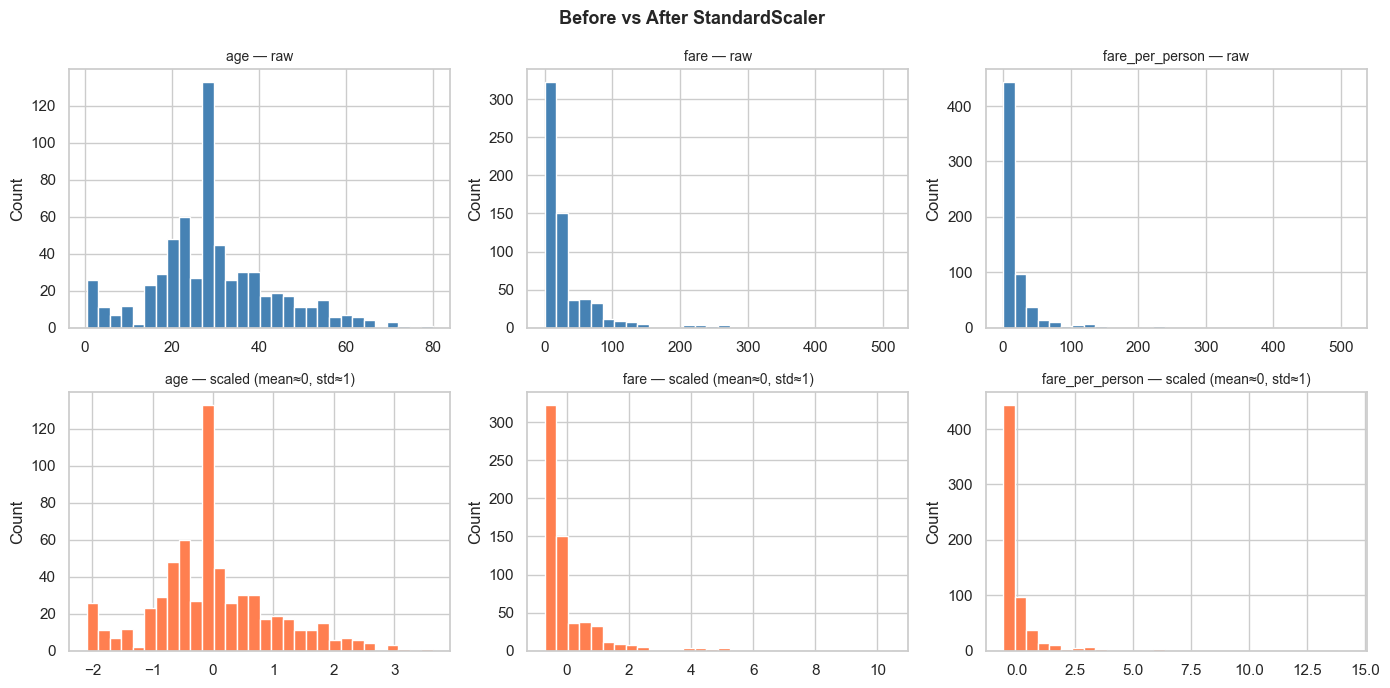

In [13]:
# Visualise before vs after scaling for key numeric features
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
raw_cols  = ['age', 'fare', 'fare_per_person']
proc_idxs = [numeric_features.index(c) for c in raw_cols]

for i, (raw_col, proc_idx) in enumerate(zip(raw_cols, proc_idxs)):
    axes[0, i].hist(X_train[raw_col].dropna(), bins=30, color='steelblue', edgecolor='white')
    axes[0, i].set_title(f'{raw_col} — raw', fontsize=10)
    axes[0, i].set_ylabel('Count')

    axes[1, i].hist(X_train_df.iloc[:, proc_idx], bins=30, color='coral', edgecolor='white')
    axes[1, i].set_title(f'{raw_col} — scaled (mean≈0, std≈1)', fontsize=10)
    axes[1, i].set_ylabel('Count')

plt.suptitle('Before vs After StandardScaler', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## Step 9 — Save Pipeline and Feature-Engineered Splits


In [14]:
# ── Save fitted Pipeline ──────────────────────────────────────────────────────
models_dir = '../models'
os.makedirs(models_dir, exist_ok=True)

pipeline_path = os.path.join(models_dir, 'feature_pipeline.pkl')
joblib.dump(feature_pipeline, pipeline_path)
pipeline_kb = os.path.getsize(pipeline_path) / 1024
print(f'Pipeline saved: {pipeline_path}  ({pipeline_kb:.1f} KB)')

# Smoke test: reload and re-transform, verify outputs match exactly
# Cast to float64 first — ColumnTransformer may output object dtype when
# numeric transformers (float64) and passthrough ints are concatenated
reloaded = joblib.load(pipeline_path)
X_test_recheck = reloaded.transform(X_test)
match = np.allclose(
    X_test_processed.astype(np.float64),
    X_test_recheck.astype(np.float64)
)
print(f'Reload smoke test:  outputs match = {match}  {"✅" if match else "❌"}')


Pipeline saved: ../models/feature_pipeline.pkl  (4.4 KB)
Reload smoke test:  outputs match = True  ✅


In [15]:
# ── Save feature-engineered splits ───────────────────────────────────────────
processed_dir = '../data/processed'
os.makedirs(processed_dir, exist_ok=True)

X_train_df.to_parquet(os.path.join(processed_dir, 'X_train.parquet'), index=True)
X_test_df.to_parquet( os.path.join(processed_dir, 'X_test.parquet'),  index=True)
y_train.to_csv(os.path.join(processed_dir, 'y_train.csv'), header=True)
y_test.to_csv( os.path.join(processed_dir, 'y_test.csv'),  header=True)

print('Saved splits:')
for fname in ['X_train.parquet', 'X_test.parquet', 'y_train.csv', 'y_test.csv']:
    path = os.path.join(processed_dir, fname)
    print(f'  {path}  ({os.path.getsize(path) / 1024:.1f} KB)')


Saved splits:
  ../data/processed/X_train.parquet  (20.3 KB)
  ../data/processed/X_test.parquet  (12.9 KB)
  ../data/processed/y_train.csv  (3.6 KB)
  ../data/processed/y_test.csv  (0.9 KB)


In [16]:
# ── Final reload verification ─────────────────────────────────────────────────
X_train_v = pd.read_parquet(os.path.join(processed_dir, 'X_train.parquet'))
X_test_v  = pd.read_parquet(os.path.join(processed_dir, 'X_test.parquet'))
y_train_v = pd.read_csv(os.path.join(processed_dir, 'y_train.csv'), index_col=0).squeeze()
y_test_v  = pd.read_csv(os.path.join(processed_dir, 'y_test.csv'),  index_col=0).squeeze()

print('=== Reload Verification ===')
print(f'X_train: {X_train_v.shape}  ✅')
print(f'X_test:  {X_test_v.shape}   ✅')
print(f'y_train: {y_train_v.shape}  ✅')
print(f'y_test:  {y_test_v.shape}   ✅')
print(f'\nFeatures: {list(X_train_v.columns)}')


=== Reload Verification ===
X_train: (627, 14)  ✅
X_test:  (157, 14)   ✅
y_train: (627,)  ✅
y_test:  (157,)   ✅

Features: ['pclass', 'age', 'sibsp', 'parch', 'fare', 'family_size', 'fare_per_person', 'sex_female', 'sex_male', 'embarked_C', 'embarked_Q', 'embarked_S', 'is_alone', 'alone']


## Summary — What We Did

| Step | What happened | Key insight |
|---|---|---|
| **Audit** | Dropped `alive` (leakage), `class`, `who`, `adult_male`, `deck`, `embark_town` | Always audit before engineering |
| **Interaction features** | `family_size`, `is_alone`, `fare_per_person` | Domain knowledge beats raw features |
| **Split first** | `train_test_split` before any fitting | The most critical ordering rule in ML |
| **Pipeline** | `ColumnTransformer`: median impute + StandardScale numeric, mode impute + OHE categorical | Reproducible, production-safe |
| **Fit on train only** | `fit_transform(X_train)`, `transform(X_test)` | No test statistics leaked into training |
| **Saved** | `models/feature_pipeline.pkl` + 4 split files in `data/processed/` | Stage 3 loads these directly |

---

## What Comes Next — Stage 3: Model Training

Load `X_train.parquet`, `X_test.parquet`, `y_train.csv`, `y_test.csv` in the next notebook.  
We will:
- Train Logistic Regression (baseline) and Random Forest
- Evaluate: Accuracy, Precision, Recall, F1, AUC-ROC
- Plot Confusion Matrix and ROC Curve for each model
- Select and save the best model to `models/titanic_model_v1.pkl`
